In [ ]:
# ============================================================
# ENTRENAMIENTO Y VALIDACIÓN DEL MODELO DE REGRESIÓN
# ============================================================


# 1. IMPORTACIÓN DE LIBRERÍAS

import io
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    cross_validate
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# 2. CONFIGURACIÓN

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


# 3. SUBIR EL DATASET DE REGRESIÓN

print(
    "Selecciona el archivo "
    "df_regresion_estudiantes.csv"
)

archivos_subidos = files.upload()

nombre_archivo = list(
    archivos_subidos.keys()
)[0]

df = pd.read_csv(
    io.BytesIO(
        archivos_subidos[nombre_archivo]
    )
)

print("\nDataset cargado correctamente.")

display(df.head())

print(
    f"\nEl dataset tiene {df.shape[0]} filas "
    f"y {df.shape[1]} columnas."
)


# 4. DEFINIR VARIABLES PREDICTORAS Y OBJETIVO

variable_objetivo = "nota_final"

X = df.drop(
    columns=[variable_objetivo]
)

y = df[variable_objetivo]

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


# 5. IDENTIFICAR VARIABLES NUMÉRICAS Y CATEGÓRICAS

columnas_numericas = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

columnas_categoricas = (
    X.select_dtypes(include="object")
    .columns
    .tolist()
)

print("\nVariables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)


# 6. SEPARAR ENTRENAMIENTO Y PRUEBA

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

print(
    "\nRegistros para entrenamiento:",
    X_train.shape[0]
)

print(
    "Registros para prueba:",
    X_test.shape[0]
)


# 7. CREAR EL PREPROCESADOR

preprocesador = ColumnTransformer(
    transformers=[
        (
            "variables_numericas",
            StandardScaler(),
            columnas_numericas
        ),
        (
            "variables_categoricas",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            columnas_categoricas
        )
    ]
)


# 8. CREAR EL PIPELINE DE REGRESIÓN

modelo_regresion = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador
        ),
        (
            "modelo",
            LinearRegression()
        )
    ]
)


# 9. ENTRENAR EL MODELO

modelo_regresion.fit(
    X_train,
    y_train
)

print(
    "\nModelo de regresión entrenado correctamente."
)


# 10. REALIZAR PREDICCIONES

prediccion_train = (
    modelo_regresion.predict(X_train)
)

prediccion_test = (
    modelo_regresion.predict(X_test)
)


# 11. CALCULAR MÉTRICAS

metricas = pd.DataFrame({
    "conjunto": [
        "Entrenamiento",
        "Prueba"
    ],
    "R2": [
        r2_score(
            y_train,
            prediccion_train
        ),
        r2_score(
            y_test,
            prediccion_test
        )
    ],
    "MAE": [
        mean_absolute_error(
            y_train,
            prediccion_train
        ),
        mean_absolute_error(
            y_test,
            prediccion_test
        )
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                y_train,
                prediccion_train
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                prediccion_test
            )
        )
    ]
})

print("\nMétricas del modelo:")

display(metricas.round(3))


# 12. VALIDACIÓN CRUZADA

resultados_cv = cross_validate(
    modelo_regresion,
    X,
    y,
    cv=5,
    scoring={
        "R2": "r2",
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error"
    }
)

resumen_cv = pd.DataFrame({
    "métrica": [
        "R2 medio",
        "MAE medio",
        "RMSE medio"
    ],
    "resultado": [
        resultados_cv["test_R2"].mean(),
        -resultados_cv["test_MAE"].mean(),
        -resultados_cv["test_RMSE"].mean()
    ]
})

print(
    "\nResultados medios de la validación cruzada:"
)

display(resumen_cv.round(3))


# 13. GRÁFICO DE VALORES REALES Y PREDICHOS

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=prediccion_test,
    alpha=0.7,
    color="steelblue"
)

valor_minimo = min(
    y_test.min(),
    prediccion_test.min()
)

valor_maximo = max(
    y_test.max(),
    prediccion_test.max()
)

plt.plot(
    [valor_minimo, valor_maximo],
    [valor_minimo, valor_maximo],
    color="red",
    linestyle="--",
    label="Predicción perfecta"
)

plt.title(
    "Comparación entre notas reales y predichas"
)

plt.xlabel("Nota final real")
plt.ylabel("Nota final predicha")
plt.legend()
plt.tight_layout()
plt.show()


# 14. ANÁLISIS DE RESIDUOS

residuos = y_test - prediccion_test

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=prediccion_test,
    y=residuos,
    alpha=0.7,
    color="darkorange"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residuos del modelo de regresión")
plt.xlabel("Nota final predicha")
plt.ylabel("Residuo")
plt.tight_layout()
plt.show()


# 15. DISTRIBUCIÓN DE LOS RESIDUOS

plt.figure(figsize=(8, 5))

sns.histplot(
    residuos,
    bins=25,
    kde=True,
    color="mediumpurple"
)

plt.title("Distribución de los residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


# 16. TABLA DE PREDICCIONES

comparacion = pd.DataFrame({
    "nota_real": y_test,
    "nota_predicha": prediccion_test,
    "error": residuos
})

print("\nEjemplo de predicciones:")

display(
    comparacion
    .head(10)
    .round(2)
)


# 17. ENTRENAR EL MODELO FINAL CON TODOS LOS DATOS

modelo_regresion.fit(X, y)


# 18. GUARDAR Y DESCARGAR EL MODELO

joblib.dump(
    modelo_regresion,
    "modelo_regresion_estudiantes.pkl"
)

print(
    "\nModelo final guardado como "
    "modelo_regresion_estudiantes.pkl"
)

files.download(
    "modelo_regresion_estudiantes.pkl"
)

Selecciona el archivo df_regresion_estudiantes.csv


Saving dataset_estudiantes.csv to dataset_estudiantes.csv

Dataset cargado correctamente.


,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1



El dataset tiene 1000 filas y 11 columnas.

Dimensiones de X: (1000, 10)
Dimensiones de y: (1000,)

Variables numéricas:
['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad', 'aprobado']

Variables categóricas:
['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']

Registros para entrenamiento: 800
Registros para prueba: 200


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# CORRECCIÓN DEL TRATAMIENTO DE VALORES NULOS

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression


# Pipeline para variables numéricas:
# sustituye nulos por la mediana y escala los datos

pipeline_numerico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="median")
        ),
        (
            "escalado",
            StandardScaler()
        )
    ]
)


# Pipeline para variables categóricas:
# sustituye nulos por la categoría más frecuente y codifica

pipeline_categorico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "codificacion",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)


# Unir los dos tratamientos

preprocesador = ColumnTransformer(
    transformers=[
        (
            "variables_numericas",
            pipeline_numerico,
            columnas_numericas
        ),
        (
            "variables_categoricas",
            pipeline_categorico,
            columnas_categoricas
        )
    ]
)


# Crear nuevamente el modelo completo

modelo_regresion = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador
        ),
        (
            "modelo",
            LinearRegression()
        )
    ]
)


# Entrenar el modelo

modelo_regresion.fit(
    X_train,
    y_train
)

print(
    "Modelo entrenado correctamente "
    "sin problemas de valores nulos."
)


# Realizar nuevamente las predicciones

prediccion_train = modelo_regresion.predict(
    X_train
)

prediccion_test = modelo_regresion.predict(
    X_test
)

print("Predicciones realizadas correctamente.")

Modelo entrenado correctamente sin problemas de valores nulos.
Predicciones realizadas correctamente.


Métricas del modelo:


,conjunto,R2,MAE,RMSE
0,Entrenamiento,0.540,5.257,6.566
1,Prueba,0.484,5.271,6.497



Resultados medios de validación cruzada:


,métrica,resultado
0,R2 medio,0.515
1,MAE medio,5.333
2,RMSE medio,6.629


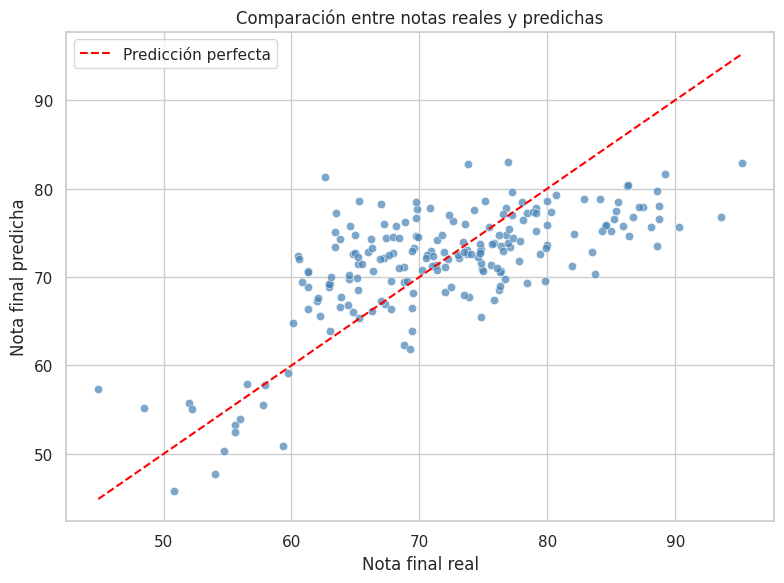

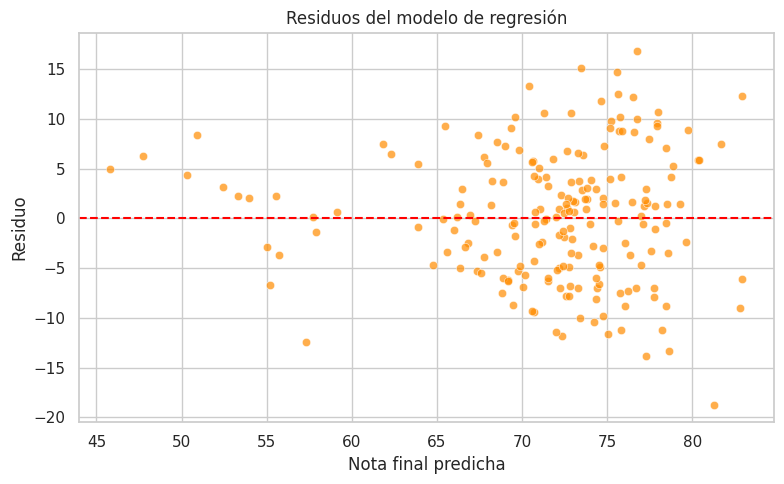

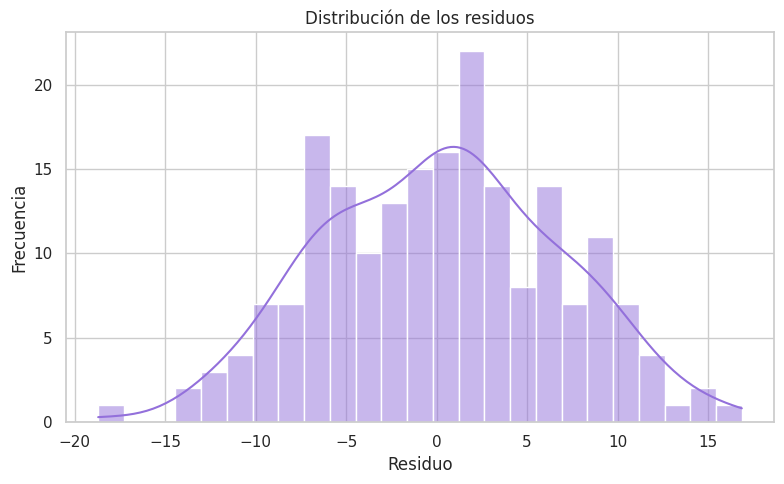


Ejemplo de predicciones:


,nota_real,nota_predicha,error
521,78.4,77.18,1.22
737,79.1,77.84,1.26
740,52.0,55.72,-3.72
660,71.9,72.84,-0.94
411,73.6,76.04,-2.44
678,76.9,82.95,-6.05
626,71.3,71.38,-0.08
513,70.9,72.96,-2.06
859,87.5,77.95,9.55
136,73.9,67.78,6.12



Modelo guardado correctamente como modelo_regresion_estudiantes.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# EVALUACIÓN DEL MODELO DE REGRESIÓN
# ============================================================


# 1. MÉTRICAS DE ENTRENAMIENTO Y PRUEBA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

metricas = pd.DataFrame({
    "conjunto": [
        "Entrenamiento",
        "Prueba"
    ],
    "R2": [
        r2_score(y_train, prediccion_train),
        r2_score(y_test, prediccion_test)
    ],
    "MAE": [
        mean_absolute_error(
            y_train,
            prediccion_train
        ),
        mean_absolute_error(
            y_test,
            prediccion_test
        )
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                y_train,
                prediccion_train
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                prediccion_test
            )
        )
    ]
})

print("Métricas del modelo:")

display(metricas.round(3))


# 2. VALIDACIÓN CRUZADA

from sklearn.model_selection import cross_validate

resultados_cv = cross_validate(
    modelo_regresion,
    X,
    y,
    cv=5,
    scoring={
        "R2": "r2",
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error"
    }
)

resumen_cv = pd.DataFrame({
    "métrica": [
        "R2 medio",
        "MAE medio",
        "RMSE medio"
    ],
    "resultado": [
        resultados_cv["test_R2"].mean(),
        -resultados_cv["test_MAE"].mean(),
        -resultados_cv["test_RMSE"].mean()
    ]
})

print(
    "\nResultados medios de validación cruzada:"
)

display(resumen_cv.round(3))


# 3. GRÁFICO DE NOTAS REALES Y PREDICHAS

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=prediccion_test,
    alpha=0.7,
    color="steelblue"
)

valor_minimo = min(
    y_test.min(),
    prediccion_test.min()
)

valor_maximo = max(
    y_test.max(),
    prediccion_test.max()
)

plt.plot(
    [valor_minimo, valor_maximo],
    [valor_minimo, valor_maximo],
    color="red",
    linestyle="--",
    label="Predicción perfecta"
)

plt.title(
    "Comparación entre notas reales y predichas"
)

plt.xlabel("Nota final real")
plt.ylabel("Nota final predicha")
plt.legend()
plt.tight_layout()
plt.show()


# 4. ANÁLISIS DE RESIDUOS

residuos = y_test - prediccion_test

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=prediccion_test,
    y=residuos,
    alpha=0.7,
    color="darkorange"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residuos del modelo de regresión")
plt.xlabel("Nota final predicha")
plt.ylabel("Residuo")
plt.tight_layout()
plt.show()


# 5. DISTRIBUCIÓN DE LOS RESIDUOS

plt.figure(figsize=(8, 5))

sns.histplot(
    residuos,
    bins=25,
    kde=True,
    color="mediumpurple"
)

plt.title("Distribución de los residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


# 6. EJEMPLO DE PREDICCIONES

comparacion = pd.DataFrame({
    "nota_real": y_test,
    "nota_predicha": prediccion_test,
    "error": residuos
})

print("\nEjemplo de predicciones:")

display(
    comparacion
    .head(10)
    .round(2)
)


# 7. ENTRENAR EL MODELO FINAL

modelo_regresion.fit(X, y)


# 8. GUARDAR Y DESCARGAR EL MODELO

import joblib

joblib.dump(
    modelo_regresion,
    "modelo_regresion_estudiantes.pkl"
)

print(
    "\nModelo guardado correctamente como "
    "modelo_regresion_estudiantes.pkl"
)

files.download(
    "modelo_regresion_estudiantes.pkl"
)